In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from scripts.final_manuscript.plot_settings import set_style

set_style()
sns.set_context("notebook")

In [42]:
cell_size = pd.DataFrame()
with pd.HDFStore("../simulation_measurement_comparison/simulated_and_measured_2024_03_02.h5", "r") as store:
    for _, row in store.data_fixed_uncert.iterrows():
        cell_size = pd.concat(
            [
                cell_size,
                pd.DataFrame(
                    {
                        "fuel": ["CH4"] * 2,
                        "oxidizer": ["N2O"] * 2,
                        "diluent": [row["diluent"]] * 2,
                        "phi_nom": [row["phi_nom"]] * 2,
                        "dil_mf_nom": [row["dil_mf_nom"]] * 2,
                        "cell_size": [row["cell_size_measured"], row["cell_size_westbrook_2"]],
                        "source": ["measurement", "simulation"],
                        "uncertainty": [row["u_cell_size_measured"], np.nan],
                    }
                ),
            ]
        )
lfs = pd.read_hdf("../final_manuscript/laminar_flame_speeds_2024_09_28.h5")

# Measurements

## Cell Size

### Measured Cell Sizes

See section 3.2-3.3 of preliminary proposal for a description of measurement methods

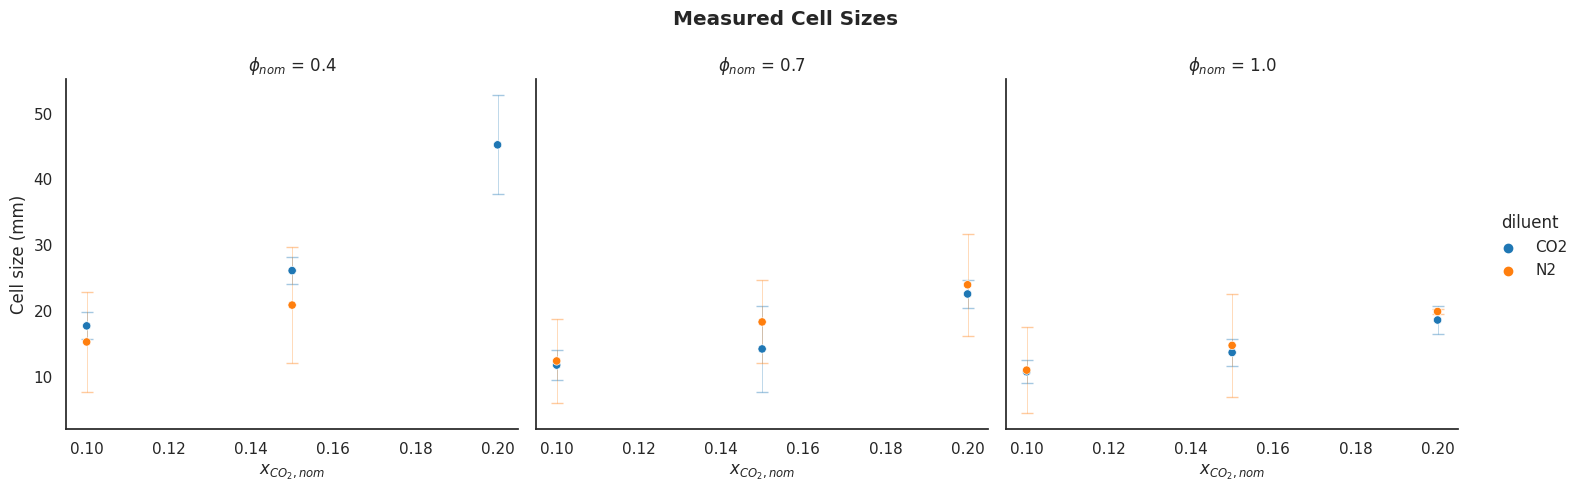

In [15]:
measurements = cell_size[cell_size["source"] == "measurement"]
grid = sns.relplot(
        x="dil_mf_nom",
        y="cell_size",
        col="phi_nom",
        hue="diluent",
        data=measurements,
        kind="scatter",
        zorder=2,
        facet_kws=dict(sharey="row"),
    )
grid.fig.suptitle("Measured Cell Sizes", weight="bold")
plot_args = dict(
    x="dil_mf_nom",
    y="cell_size",
    yerr="uncertainty",
    ls="None",
    linewidth=0.5,
    zorder=1,
    capsize=4,
    alpha=0.4,
)
grid.axes[0][0].errorbar(
    **plot_args, data=measurements[(measurements["phi_nom"] == 0.4) & (measurements["diluent"] == "CO2")]
)
grid.axes[0][0].errorbar(
    **plot_args, data=measurements[(measurements["phi_nom"] == 0.4) & (measurements["diluent"] == "N2")]
)
grid.axes[0][1].errorbar(
    **plot_args, data=measurements[(measurements["phi_nom"] == 0.7) & (measurements["diluent"] == "CO2")]
)
grid.axes[0][1].errorbar(
    **plot_args, data=measurements[(measurements["phi_nom"] == 0.7) & (measurements["diluent"] == "N2")]
)
grid.axes[0][2].errorbar(
    **plot_args, data=measurements[(measurements["phi_nom"] == 1.0) & (measurements["diluent"] == "CO2")]
)
grid.axes[0][2].errorbar(
    **plot_args, data=measurements[(measurements["phi_nom"] == 1.0) & (measurements["diluent"] == "N2")]
)

for ax in grid.axes.flatten():
    title = ax.get_title()
    ax.set_title(
        title.replace("source = ", "")
        .replace("measurement ", "Measured")
        .replace("simulation ", "Simulated")
        .replace("| ", "\n")
        .replace("phi_nom", r"$\phi_{nom}$")
    )
    if ax.get_xlabel():
        ax.set_xlabel("$x_{CO_{2},nom}$")
    if ax.get_ylabel():
        ax.set_ylabel("Cell size (mm)")
grid.tight_layout();

### Cell Size Measurements vs. Simulations

See section 3.4 of preliminary proposal for a description of simulation methods

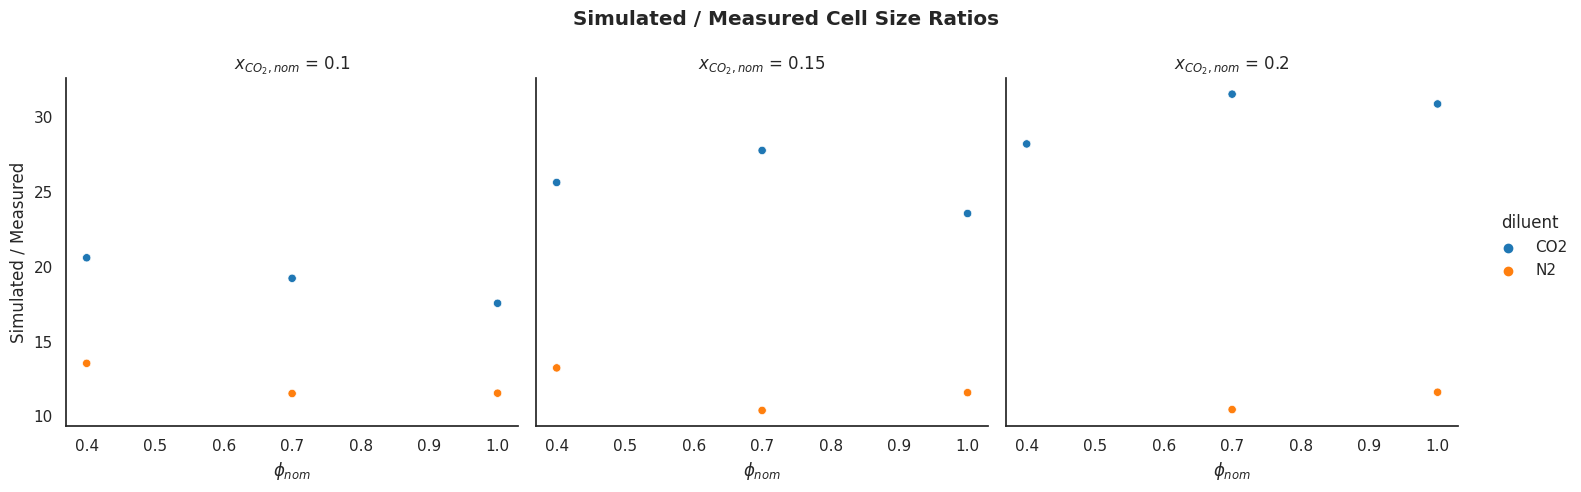

In [19]:
ratio = (
    cell_size[cell_size["source"] == "simulation"].set_index(["dil_mf_nom", "phi_nom", "fuel", "oxidizer", "diluent"])[
        "cell_size"
    ]
    / cell_size[cell_size["source"] == "measurement"].set_index(["dil_mf_nom", "phi_nom", "fuel", "oxidizer", "diluent"])[
        "cell_size"
    ]
)
ratio.name = "ratio"
ratio = ratio.reset_index()
grid = sns.relplot(x="phi_nom", y="ratio", col="dil_mf_nom", hue="diluent", data=ratio)
grid.fig.suptitle("Simulated / Measured Cell Size Ratios", weight="bold")
for ax in grid.axes.flatten():
    title = ax.get_title()
    ax.set_title(title.replace("dil_mf_nom", "$x_{CO_{2},nom}$"))
    if ax.get_xlabel():
        ax.set_xlabel(r"$\phi_{nom}$")
    if ax.get_ylabel():
        ax.set_ylabel("Simulated / Measured")
grid.tight_layout();

We see a divergence between N2 and CO2 diluted measurements and simulations of cell sizes corresponding to CO2 mole fraction

## Wave Speed

### Measured Wave Speed

See section 3.2-3.3 of preliminary proposal for a description of measurement methods

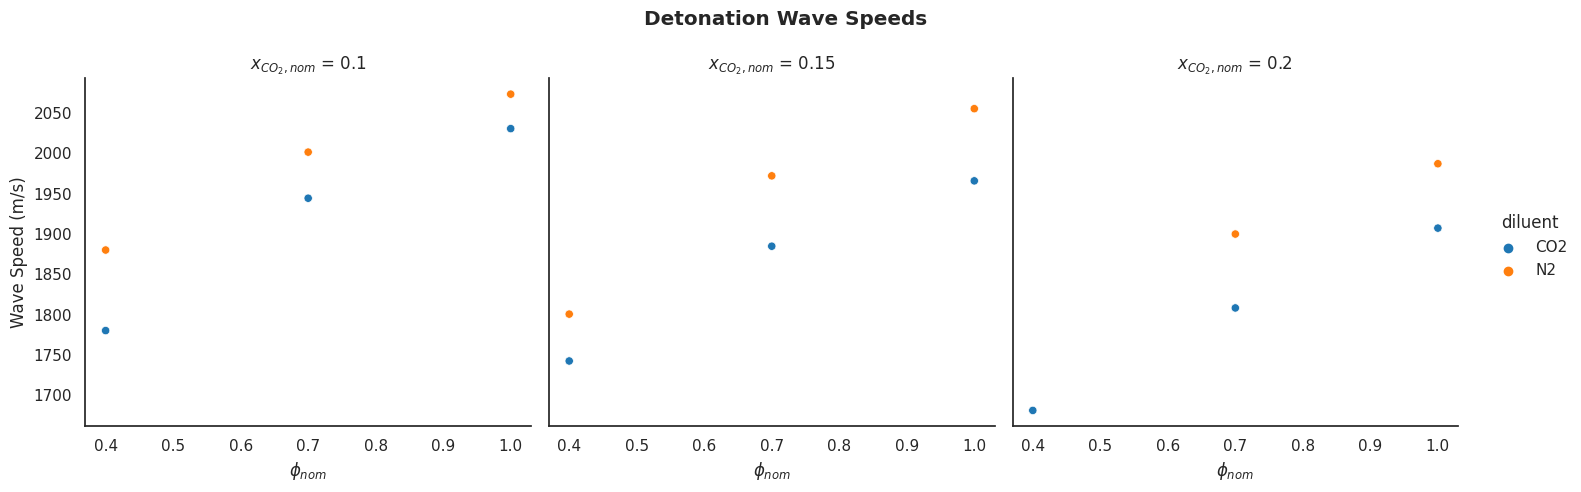

In [43]:
grid = sns.relplot(x="phi_nom", y="wave_speed", col="dil_mf_nom", hue="diluent", data=lfs)
grid.fig.suptitle("Detonation Wave Speeds", weight="bold")
for ax in grid.axes.flatten():
    title = ax.get_title()
    ax.set_title(title.replace("dil_mf_nom", "$x_{CO_{2},nom}$"))
    if ax.get_xlabel():
        ax.set_xlabel(r"$\phi_{nom}$")
    if ax.get_ylabel():
        ax.set_ylabel("Wave Speed (m/s)")
grid.tight_layout();

### CJ Speed

See section 3.4 of preliminary proposal for a description of CJ speed calculation methods

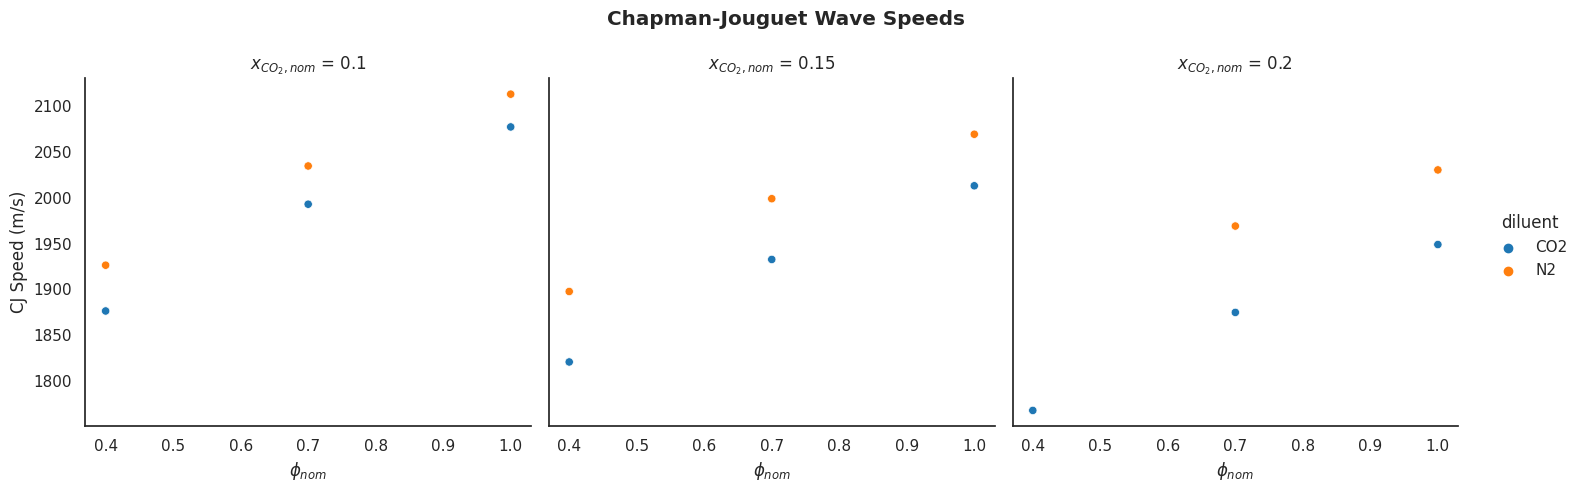

In [47]:
grid = sns.relplot(x="phi_nom", y="cj", col="dil_mf_nom", hue="diluent", data=lfs)
grid.fig.suptitle("Chapman-Jouguet Wave Speeds", weight="bold")
for ax in grid.axes.flatten():
    title = ax.get_title()
    ax.set_title(title.replace("dil_mf_nom", "$x_{CO_{2},nom}$"))
    if ax.get_xlabel():
        ax.set_xlabel(r"$\phi_{nom}$")
    if ax.get_ylabel():
        ax.set_ylabel("CJ Speed (m/s)")
grid.tight_layout();

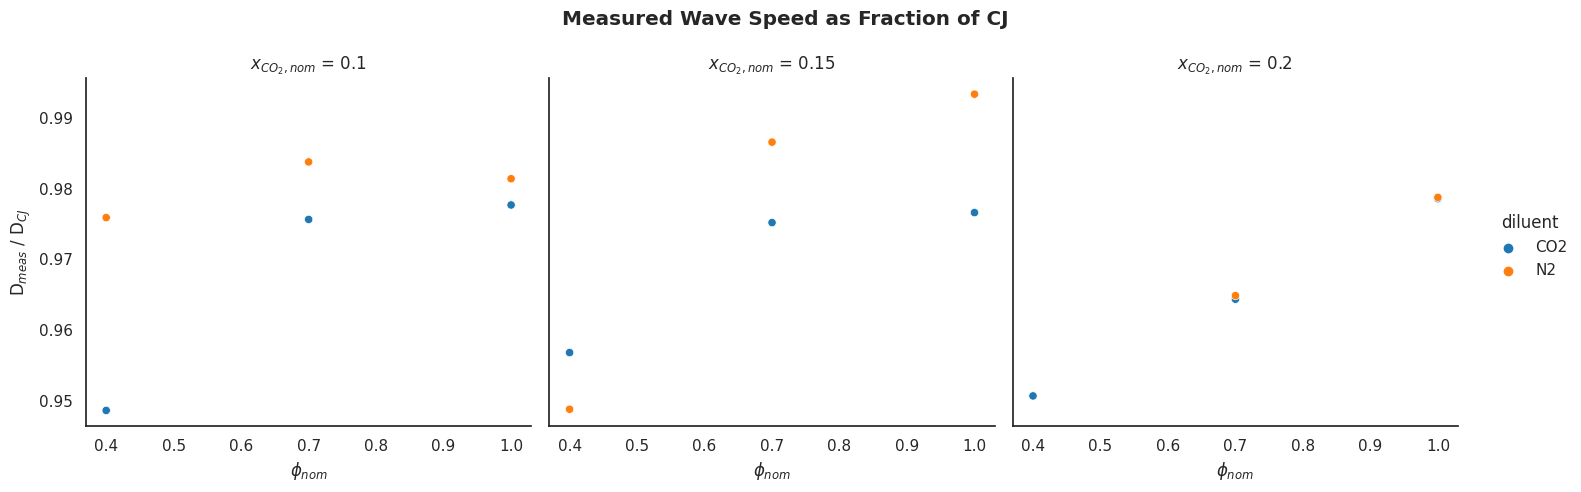

In [48]:
lfs["cj_ratio"] = lfs["wave_speed"] / lfs["cj"]
grid = sns.relplot(x="phi_nom", y="cj_ratio", col="dil_mf_nom", hue="diluent", data=lfs)
grid.fig.suptitle("Measured Wave Speed as Fraction of CJ", weight="bold")
for ax in grid.axes.flatten():
    title = ax.get_title()
    ax.set_title(title.replace("dil_mf_nom", "$x_{CO_{2},nom}$"))
    if ax.get_xlabel():
        ax.set_xlabel(r"$\phi_{nom}$")
    if ax.get_ylabel():
        ax.set_ylabel("D$_{meas}$ / D$_{CJ}$")
grid.tight_layout();

# Potential Causes of Divergence

## Sound Speed

### Methodology

Sound speed was calculated using the `sdtoolbox.thermo.soundspeed_fr()` function. This function calculates the sound speed in a frozen reactant or product mixture (i.e. no reactions are allowed to take place during the calculation). `soundspeed_fr` uses the following methodology:

1. The density, pressure, and mass entropy of the gas mixture are collected
$$
\rho_{0}, P_{0}, S
$$
2. The mixture's density is perturbed to 100.1% of its original value while the entropy is held constant
$$
\rho_{1} = 1.001 \rho_{0}
$$
3. The perturbed density and corresponding pressure are used to calculate sensitivity of pressure to density at constant entropy
$$
\frac{dP}{d\rho}\bigg\rvert_{S} = \frac{P_{1} - P_{0}}{\rho_{1} - \rho_{0}}
$$
4. The sound speed is calculated
$$
a = \sqrt{\frac{dP}{d\rho}\bigg\rvert_{S}}
$$

### Reactants

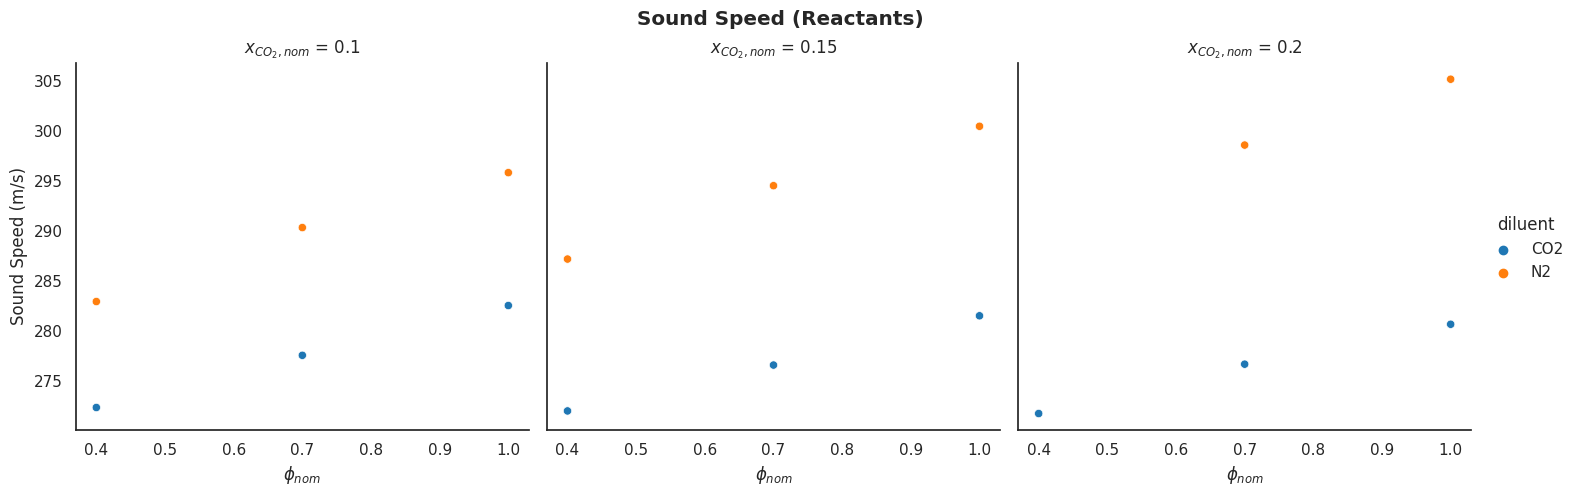

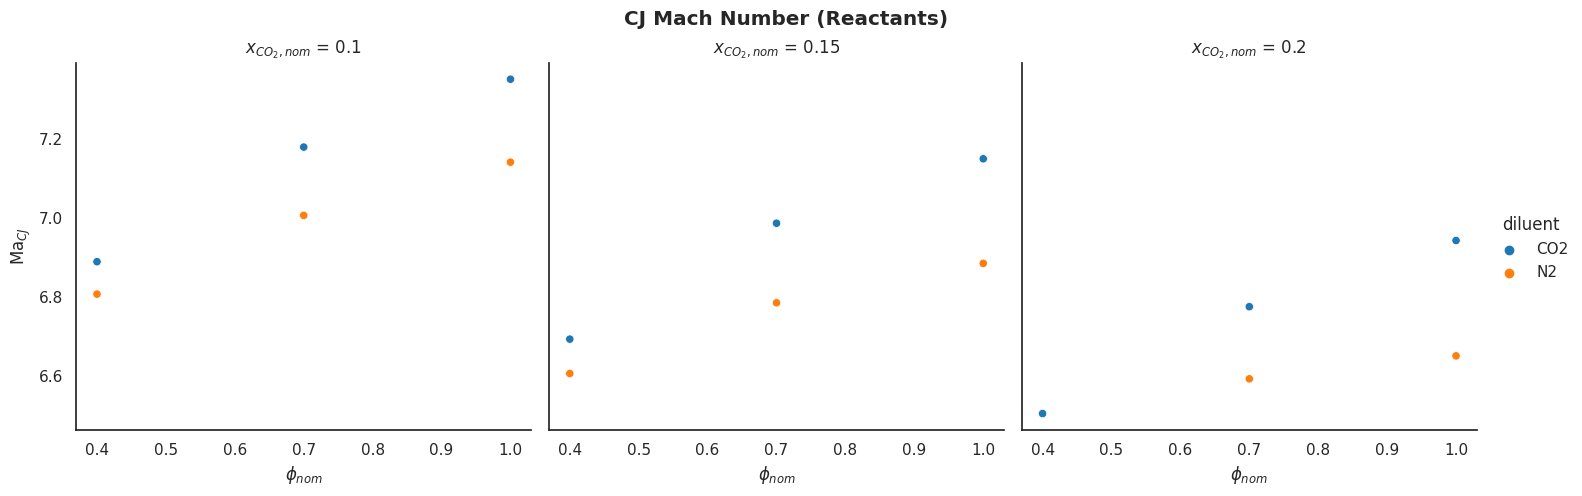

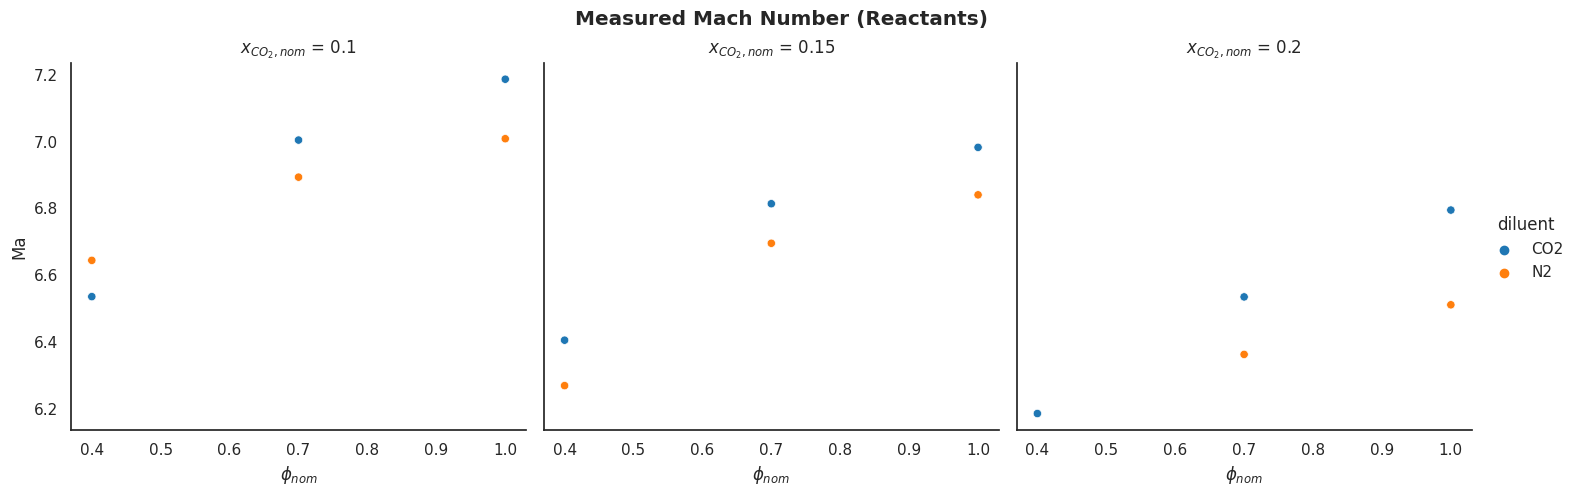

In [28]:
for title, (lbl, col) in {
    "Sound Speed (Reactants)": ("Sound Speed (m/s)", "sound_speed_reactants"),
    "CJ Mach Number (Reactants)": ("Ma$_{CJ}$", "mach_cj_reactants"),
    "Measured Mach Number (Reactants)": ("Ma", "mach_reactants"),
}.items():
    grid = sns.relplot(x="phi_nom", y=col, data=lfs, col="dil_mf_nom", hue="diluent")
    grid.fig.suptitle(title, weight="bold")
    grid.set_ylabels(lbl)
    for ax in grid.axes.flatten():
        t = ax.get_title()
        ax.set_title(t.replace("dil_mf_nom", "$x_{CO_{2},nom}$"))
        if ax.get_xlabel():
            ax.set_xlabel(r"$\phi_{nom}$")
    plt.subplots_adjust(top=0.875)

### Products

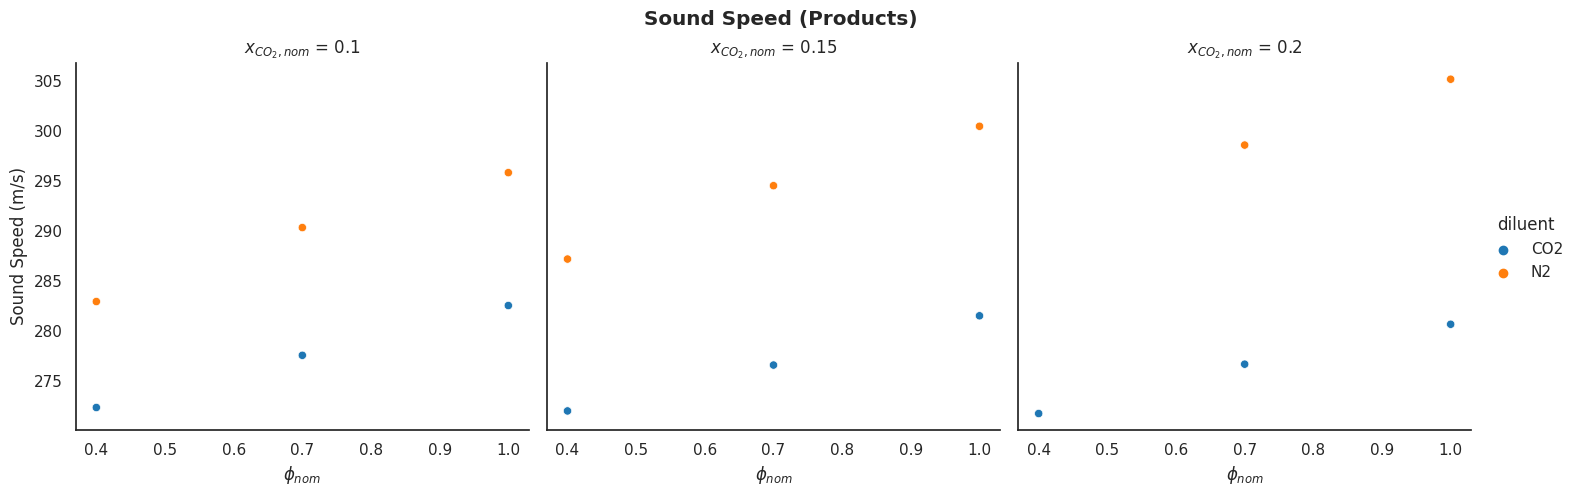

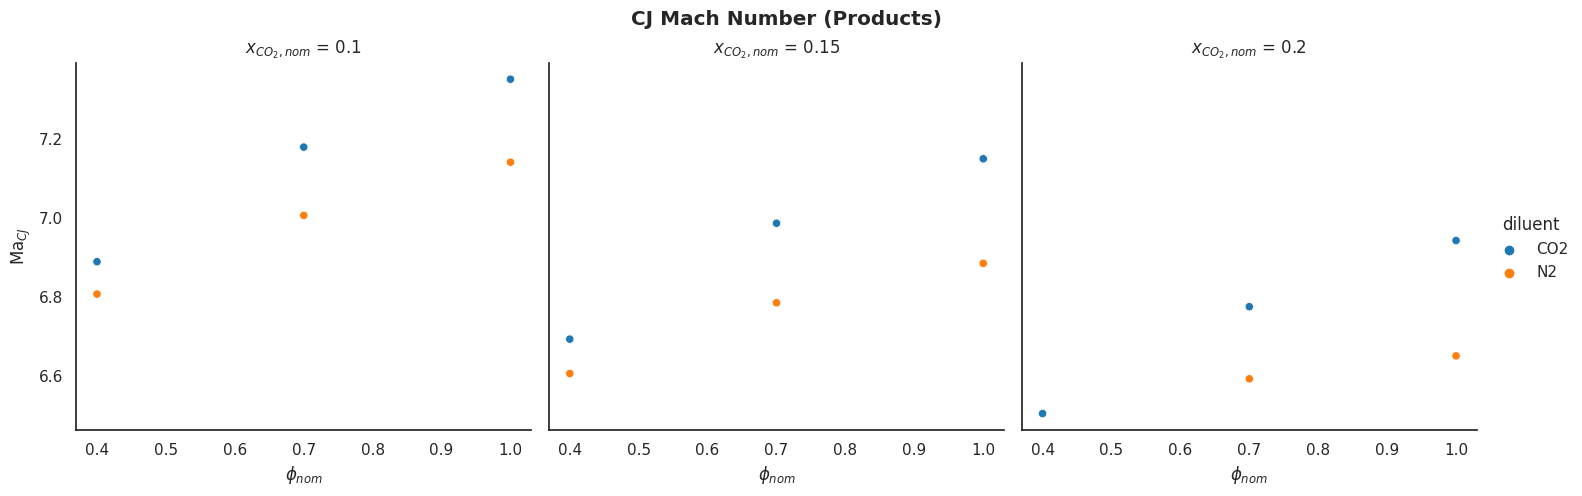

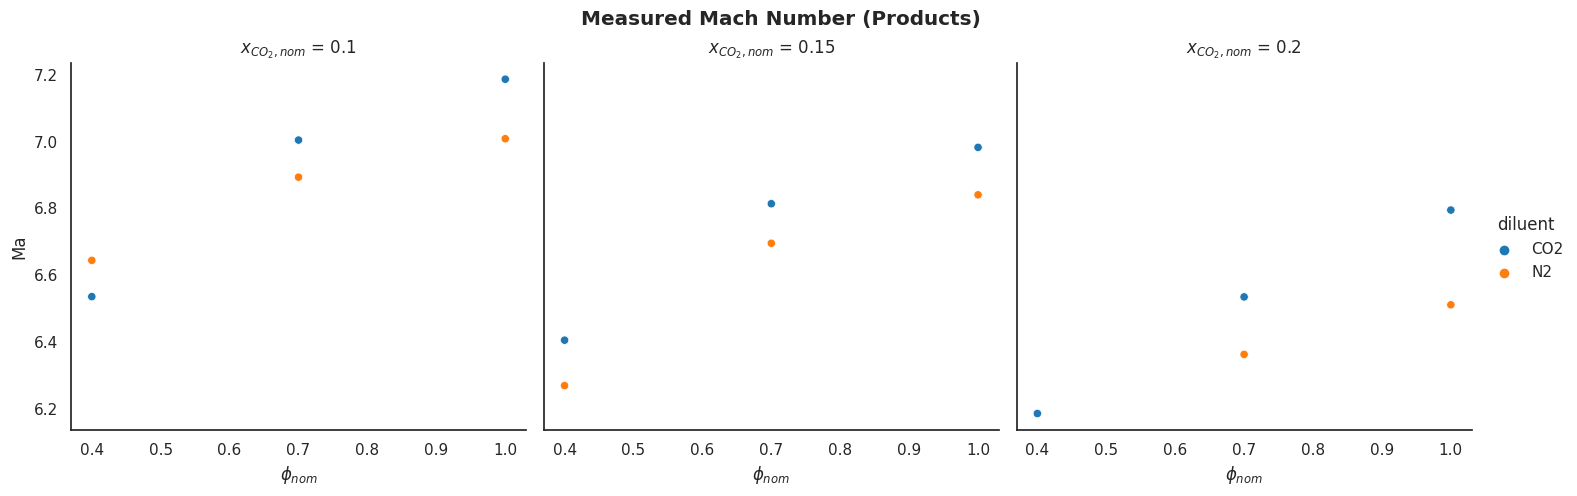

In [29]:
for title, (lbl, col) in {
    "Sound Speed (Products)": ("Sound Speed (m/s)", "sound_speed_products"),
    "CJ Mach Number (Products)": ("Ma$_{CJ}$", "mach_cj_products"),
    "Measured Mach Number (Products)": ("Ma", "mach_products"),
}.items():
    grid = sns.relplot(x="phi_nom", y=col, data=lfs, col="dil_mf_nom", hue="diluent")
    grid.fig.suptitle(title, weight="bold")
    grid.set_ylabels(lbl)
    for ax in grid.axes.flatten():
        t = ax.get_title()
        ax.set_title(t.replace("dil_mf_nom", "$x_{CO_{2},nom}$"))
        if ax.get_xlabel():
            ax.set_xlabel(r"$\phi_{nom}$")
    plt.subplots_adjust(top=0.875)

## Specific Heat Ratio

### Methodology

Specific heat ratio is calculated using the physical properties from a `cantera.Solution` object at the state of interest
$$
\frac{c_{p}}{c_{v}}
$$

### Reactants

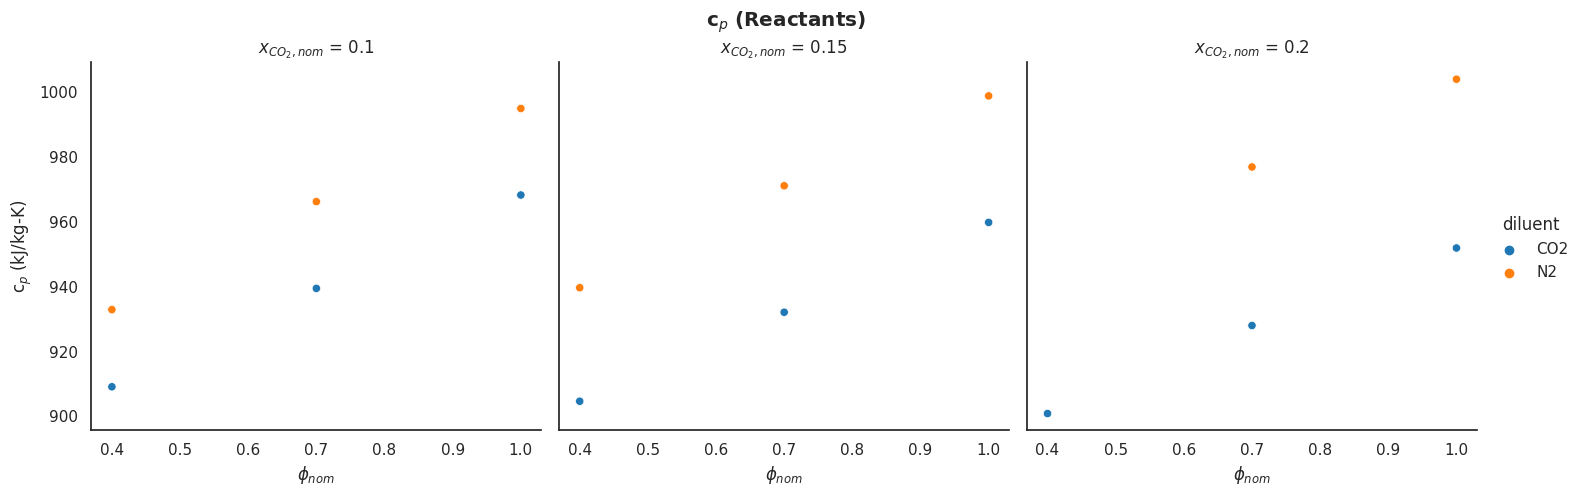

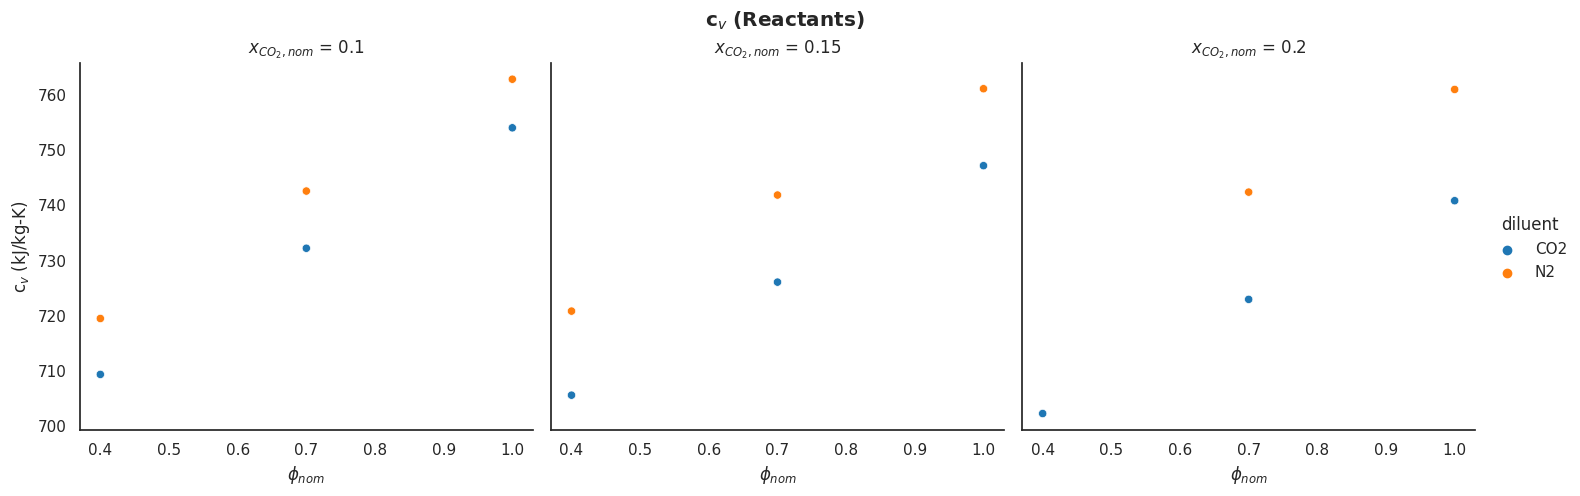

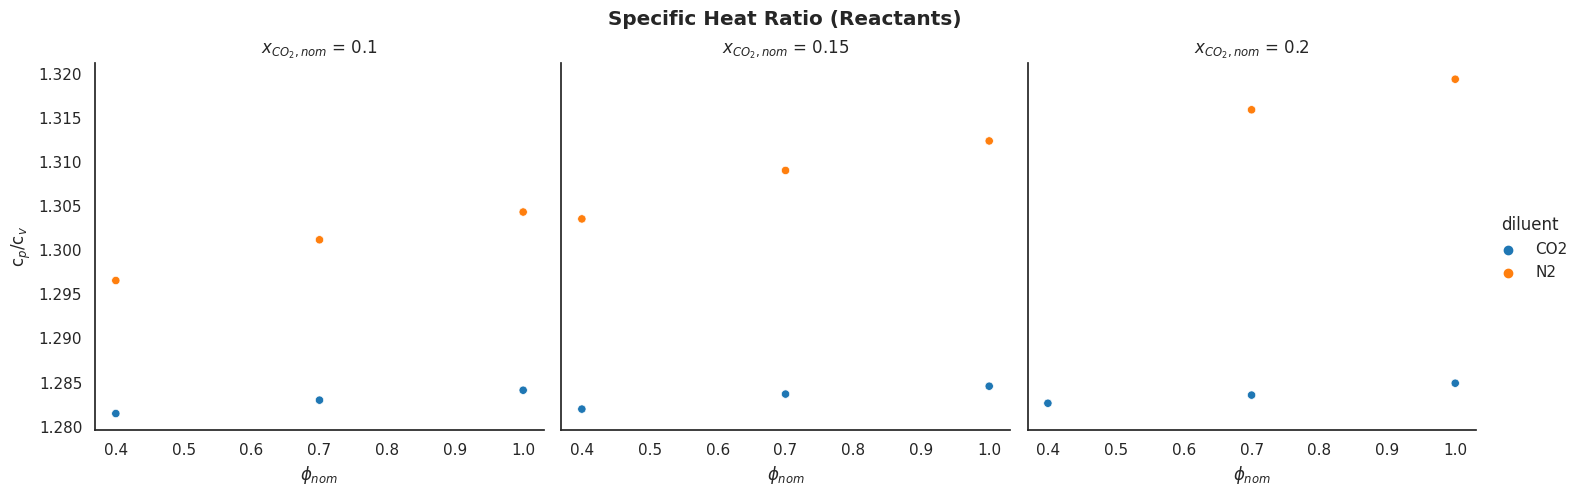

In [30]:
for title, (lbl, col) in {
    "c$_{p}$ (Reactants)": ("c$_{p}$ (kJ/kg-K)", "cp_initial"),
    "c$_{v}$ (Reactants)": ("c$_{v}$ (kJ/kg-K)", "cv_initial"),
    "Specific Heat Ratio (Reactants)": ("c$_{p}$/c$_{v}$", "spec_heat_ratio_initial"),
}.items():
    grid = sns.relplot(x="phi_nom", y=col, data=lfs, col="dil_mf_nom", hue="diluent")
    grid.fig.suptitle(title, weight="bold")
    grid.set_ylabels(lbl)
    for ax in grid.axes.flatten():
        t = ax.get_title()
        ax.set_title(t.replace("dil_mf_nom", "$x_{CO_{2},nom}$"))
        if ax.get_xlabel():
            ax.set_xlabel(r"$\phi_{nom}$")
    plt.subplots_adjust(top=0.875)

### Products

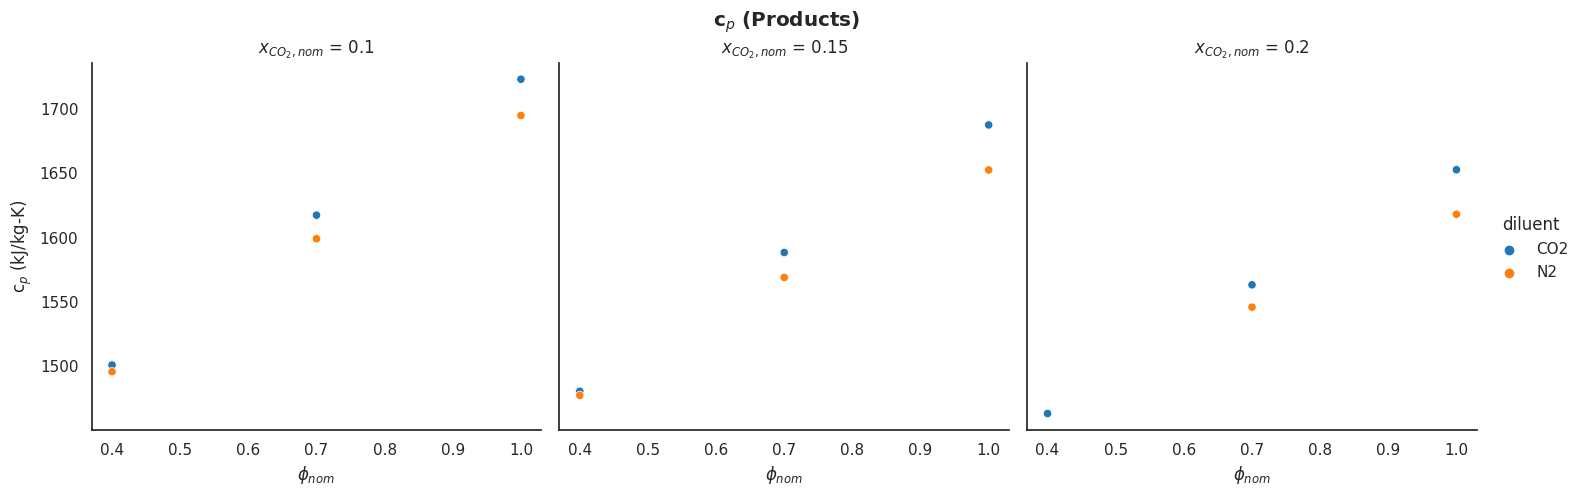

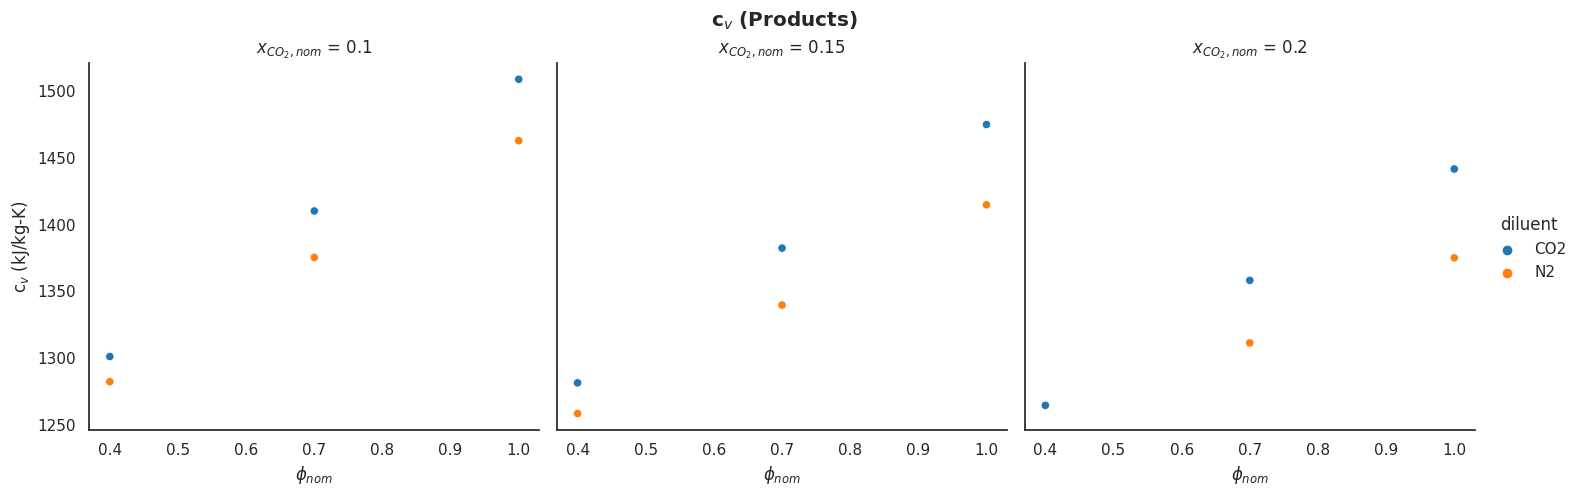

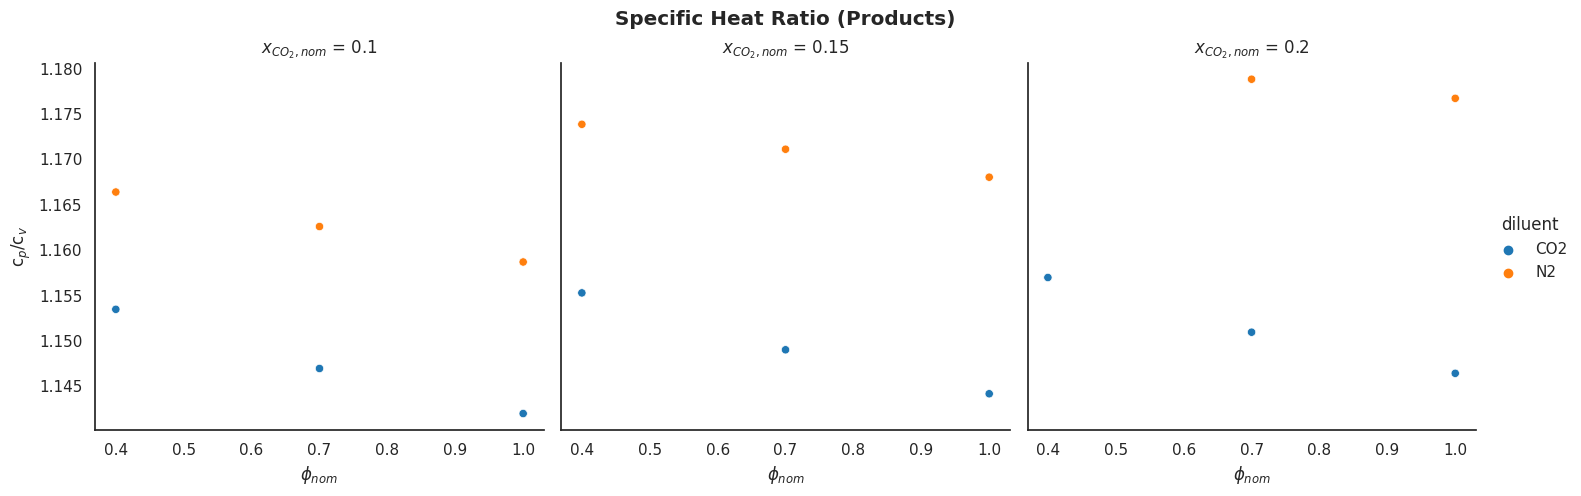

In [31]:
for title, (lbl, col) in {
    "c$_{p}$ (Products)": ("c$_{p}$ (kJ/kg-K)", "cp_ps"),
    "c$_{v}$ (Products)": ("c$_{v}$ (kJ/kg-K)", "cv_ps"),
    "Specific Heat Ratio (Products)": ("c$_{p}$/c$_{v}$", "spec_heat_ratio_ps"),
}.items():
    grid = sns.relplot(x="phi_nom", y=col, data=lfs, col="dil_mf_nom", hue="diluent")
    grid.fig.suptitle(title, weight="bold")
    grid.set_ylabels(lbl)
    for ax in grid.axes.flatten():
        t = ax.get_title()
        ax.set_title(t.replace("dil_mf_nom", "$x_{CO_{2},nom}$"))
        if ax.get_xlabel():
            ax.set_xlabel(r"$\phi_{nom}$")
    plt.subplots_adjust(top=0.875)

## Laminar Flame Speed

### Methodology

Laminar flame speed is read from the first velocity value calculated using `cantera.FreeFlame` with refine criteria of `ratio=3, slope=0.1, curve=0.1`

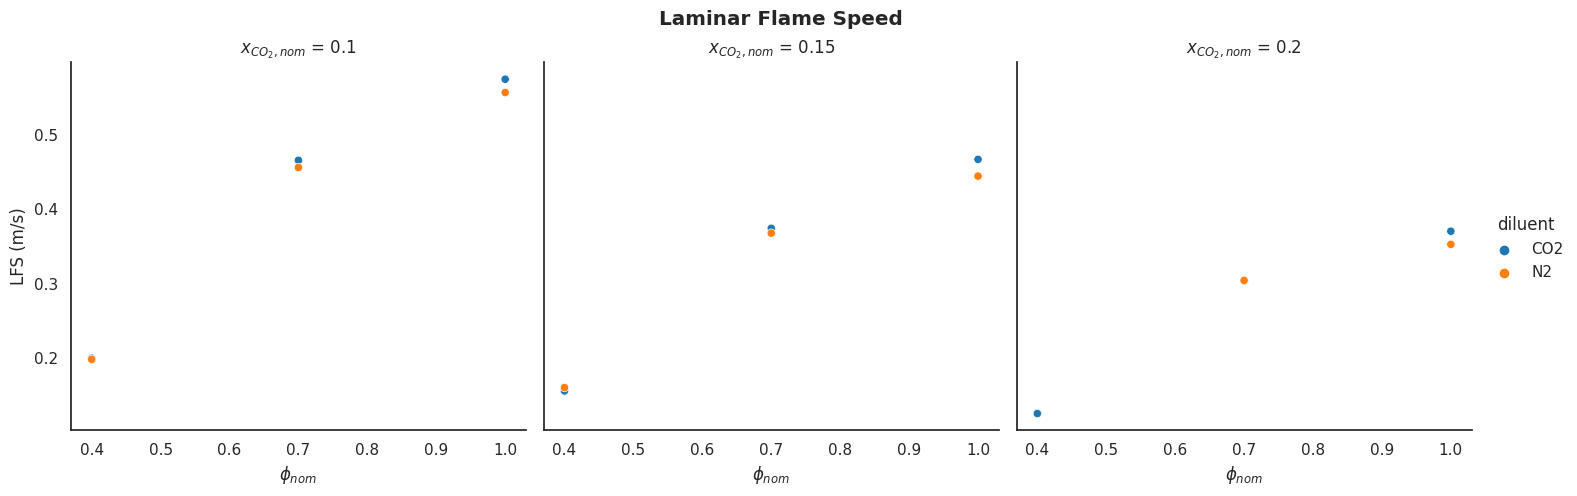

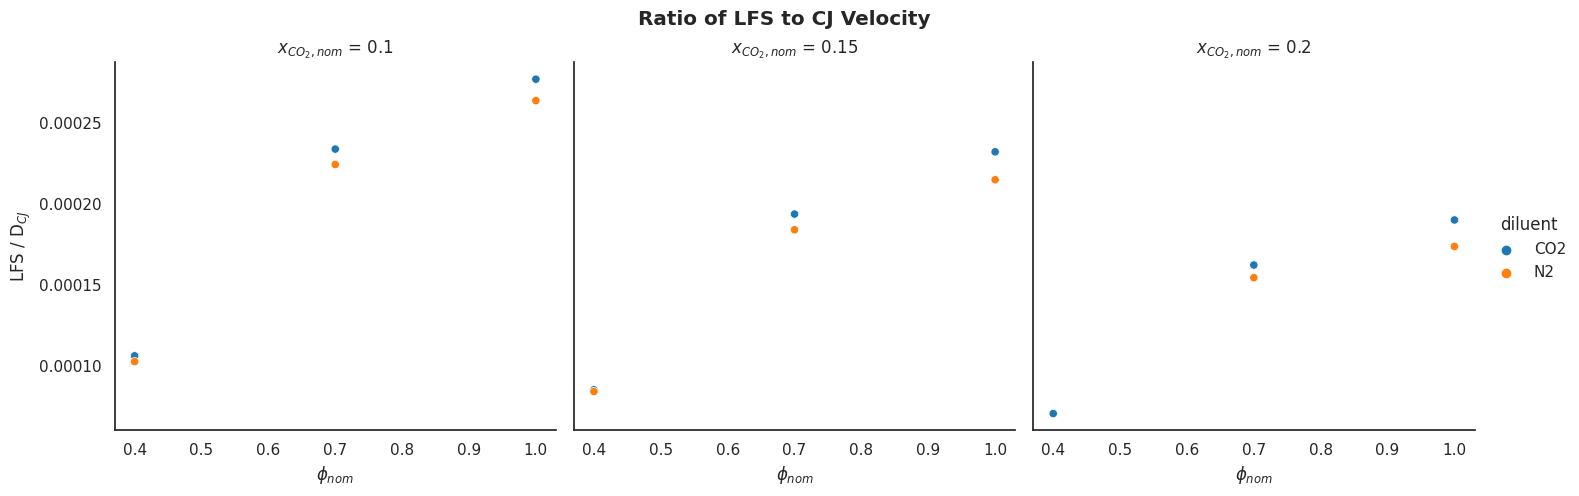

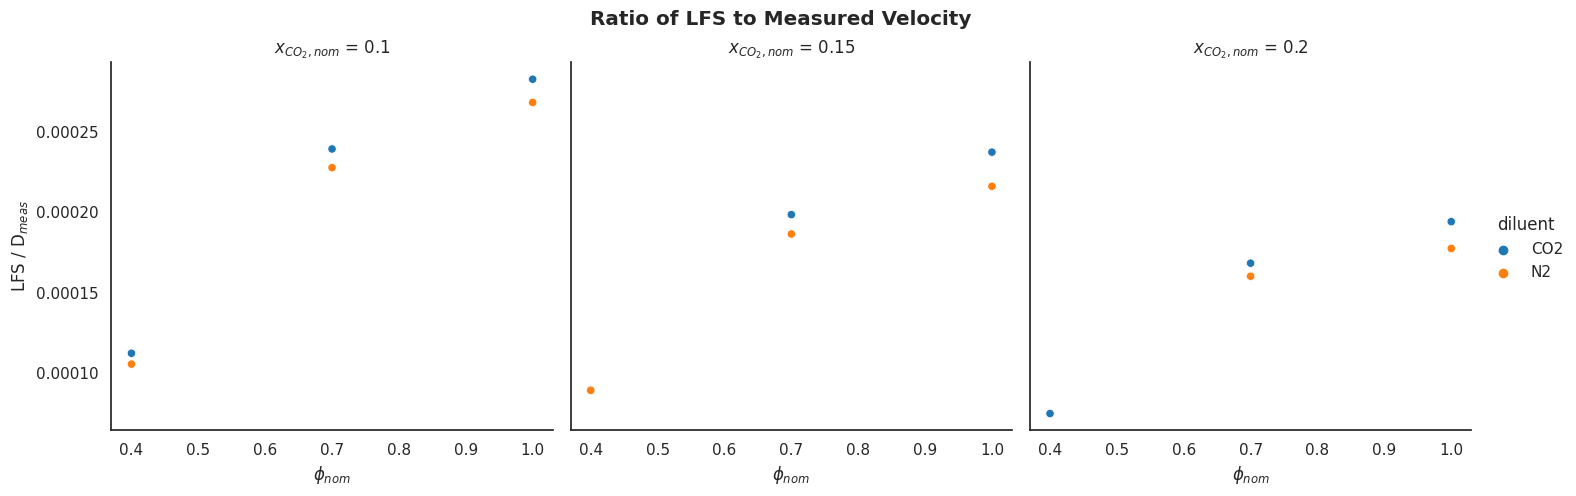

In [32]:
lfs["cj_ratio"] = lfs["lfs"] / lfs["cj"]
lfs["meas_ratio"] = lfs["lfs"] / lfs["wave_speed"]
for title, (lbl, col) in {
    "Laminar Flame Speed": ("LFS (m/s)", "lfs"),
    "Ratio of LFS to CJ Velocity": ("LFS / D$_{CJ}$", "cj_ratio"),
    "Ratio of LFS to Measured Velocity": ("LFS / D$_{meas}$", "meas_ratio"),
}.items():
    grid = sns.relplot(x="phi_nom", y=col, data=lfs, col="dil_mf_nom", hue="diluent")
    grid.fig.suptitle(title, weight="bold")
    grid.set_ylabels(lbl)
    for ax in grid.axes.flatten():
        t = ax.get_title()
        ax.set_title(t.replace("dil_mf_nom", "$x_{CO_{2},nom}$"))
        if ax.get_xlabel():
            ax.set_xlabel(r"$\phi_{nom}$")
    plt.subplots_adjust(top=0.875)